# TCGA Gene Expression SQL Analysis

**Dataset:** 801 samples · 5 cancer types · 20 high-variance genes  
**Database:** PostgreSQL (tcga_sql)  
**Goal:** Investigate gene expression patterns across cancer types using SQL — 
extending findings from the RNA-Seq EDA project.

In [1]:
# --- Imports & Database Connection ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
name = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{name}")

# Test connection
with engine.connect() as conn:
    result = pd.read_sql("SELECT COUNT(*) FROM patients;", conn)
    print(result)

   count
0    801


## Section 1 — Dataset Overview
Sample distribution across cancer types.

In [2]:
# --- Section 1: Sample Distribution per Cancer Type ---
query = """
    SELECT 
        c.cancer_type_code,
        c.full_name,
        COUNT(*) AS sample_count
    FROM patients p
    JOIN cancer_types c ON p.cancer_type_code = c.cancer_type_code
    GROUP BY c.cancer_type_code, c.full_name
    ORDER BY sample_count DESC;
"""

with engine.connect() as conn:
    df_overview = pd.read_sql(query, conn)

df_overview

,cancer_type_code,full_name,sample_count
0,BRCA,Breast Invasive Carcinoma,300
1,KIRC,Kidney Renal Clear Cell Carcinoma,146
2,LUAD,Lung Adenocarcinoma,141
3,PRAD,Prostate Adenocarcinoma,136
4,COAD,Colon Adenocarcinoma,78


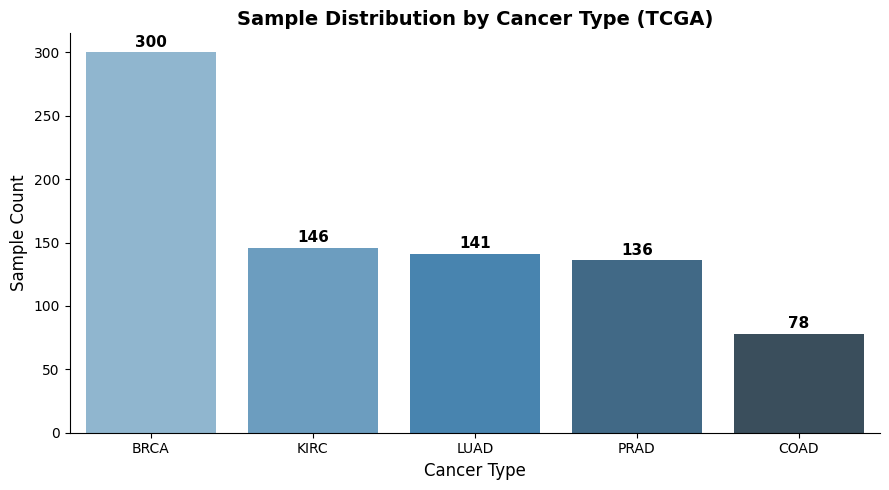

In [5]:
# --- Section 1: Visualization ---
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=df_overview,
    x="cancer_type_code",
    y="sample_count",
    hue="cancer_type_code",
    palette="Blues_d",
    legend=False,
    ax=ax
)

for bar, count in zip(ax.patches, df_overview["sample_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(count),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Sample Distribution by Cancer Type (TCGA)", fontsize=14, fontweight="bold")
ax.set_xlabel("Cancer Type", fontsize=12)
ax.set_ylabel("Sample Count", fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/section1_sample_distribution.png", dpi=150)
plt.show()

## Section 2 — Gene Expression Landscape
Average expression per gene per cancer type, identifying which cancer types 
show the highest and lowest expression across the 20 high-variance genes.

In [6]:
# --- Section 2: Average Expression per Gene per Cancer Type ---
query = """
    SELECT 
        p.cancer_type_code,
        g.gene_name,
        ROUND(AVG(g.expression_value)::numeric, 4) AS avg_expression
    FROM gene_expression g
    JOIN patients p ON g.sample_id = p.sample_id
    GROUP BY p.cancer_type_code, g.gene_name
    ORDER BY g.gene_name, avg_expression DESC;
"""

with engine.connect() as conn:
    df_expression = pd.read_sql(query, conn)

df_expression.head(10)

,cancer_type_code,gene_name,avg_expression
0,PRAD,gene_11250,13.6415
1,LUAD,gene_11250,5.9140
2,BRCA,gene_11250,4.3825
3,COAD,gene_11250,0.5541
4,KIRC,gene_11250,0.3206
5,PRAD,gene_15301,12.7480
6,KIRC,gene_15301,8.2071
7,COAD,gene_15301,6.5961
8,LUAD,gene_15301,5.9598
9,BRCA,gene_15301,0.4124


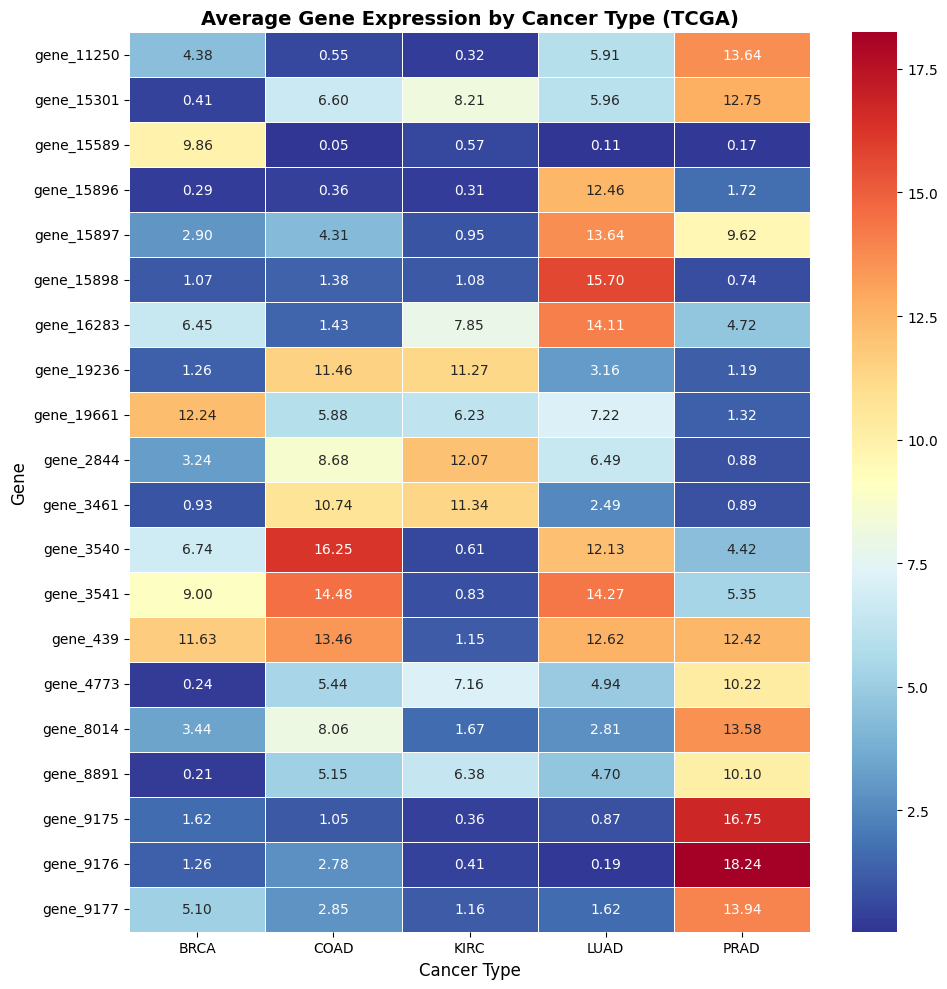

In [7]:
# --- Section 2: Visualization — Heatmap ---
df_pivot = df_expression.pivot(
    index="gene_name",
    columns="cancer_type_code",
    values="avg_expression"
)

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    df_pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Average Gene Expression by Cancer Type (TCGA)", fontsize=14, fontweight="bold")
ax.set_xlabel("Cancer Type", fontsize=12)
ax.set_ylabel("Gene", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/section2_expression_heatmap.png", dpi=150)
plt.show()

## Section 3 — Above-Average Expression
Identifying samples with expression above the global mean using a CTE,
broken down by cancer type to reveal which groups have the most 
above-average expressing samples.

In [8]:
# --- Section 3: Above-Average Expression per Cancer Type ---
query = """
    WITH overall_avg AS (
        SELECT AVG(expression_value) AS avg_val
        FROM gene_expression
    )
    SELECT 
        p.cancer_type_code,
        COUNT(*) AS above_avg_count
    FROM gene_expression g
    JOIN patients p ON g.sample_id = p.sample_id, overall_avg
    WHERE g.expression_value > overall_avg.avg_val
    GROUP BY p.cancer_type_code
    ORDER BY above_avg_count DESC;
"""

with engine.connect() as conn:
    df_above_avg = pd.read_sql(query, conn)

df_above_avg

,cancer_type_code,above_avg_count
0,BRCA,1988
1,PRAD,1536
2,LUAD,1492
3,KIRC,932
4,COAD,747


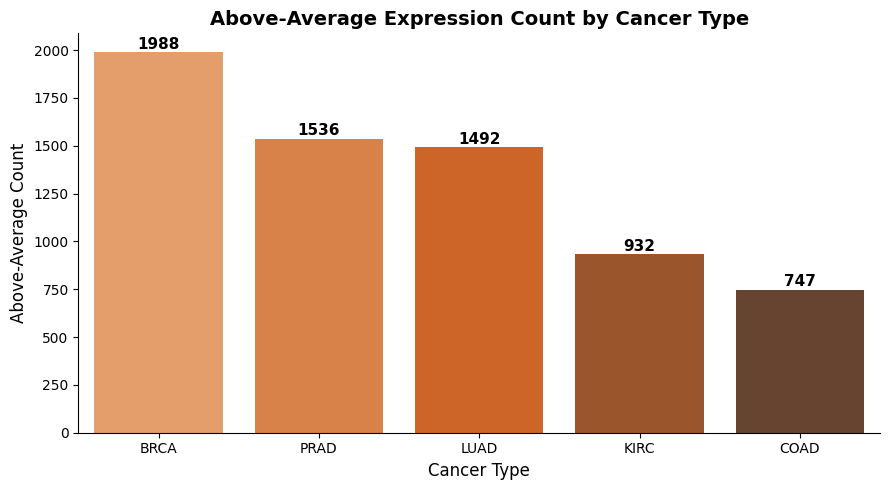

In [10]:
# --- Section 3: Visualization ---
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=df_above_avg,
    x="cancer_type_code",
    y="above_avg_count",
    hue="cancer_type_code",
    palette="Oranges_d",
    legend=False,
    ax=ax
)

for bar, count in zip(ax.patches, df_above_avg["above_avg_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(count),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Above-Average Expression Count by Cancer Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Cancer Type", fontsize=12)
ax.set_ylabel("Above-Average Count", fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/section3_above_avg_expression.png", dpi=150)
plt.show()

## Section 4 — Within-Cancer Ranking
Using window functions to rank samples by expression value within each 
cancer type, identifying the top expressing samples per group for gene_15589 
— the highest variance gene in the dataset.

In [11]:
# --- Section 4: Within-Cancer Ranking using Window Functions ---
query = """
    SELECT 
        g.sample_id,
        p.cancer_type_code,
        g.gene_name,
        ROUND(g.expression_value::numeric, 4) AS expression_value,
        ROUND(AVG(g.expression_value) OVER (PARTITION BY p.cancer_type_code)::numeric, 4) AS avg_by_cancer,
        RANK() OVER (PARTITION BY p.cancer_type_code ORDER BY g.expression_value DESC) AS rank_in_cancer
    FROM gene_expression g
    JOIN patients p ON g.sample_id = p.sample_id
    WHERE g.gene_name = 'gene_15589'
    ORDER BY p.cancer_type_code, rank_in_cancer;
"""

with engine.connect() as conn:
    df_ranked = pd.read_sql(query, conn)

# Show top 3 per cancer type
df_top3 = df_ranked[df_ranked["rank_in_cancer"] <= 3]
df_top3

,sample_id,cancer_type_code,gene_name,expression_value,avg_by_cancer,rank_in_cancer
0,sample_39,BRCA,gene_15589,18.7942,9.8612,1
1,sample_82,BRCA,gene_15589,18.7328,9.8612,2
2,sample_127,BRCA,gene_15589,18.6408,9.8612,3
300,sample_353,COAD,gene_15589,1.7320,0.0474,1
301,sample_47,COAD,gene_15589,0.7917,0.0474,2
302,sample_107,COAD,gene_15589,0.6377,0.0474,3
378,sample_679,KIRC,gene_15589,4.6306,0.5654,1
379,sample_523,KIRC,gene_15589,3.7276,0.5654,2
380,sample_446,KIRC,gene_15589,3.5741,0.5654,3
524,sample_190,LUAD,gene_15589,3.8048,0.1109,1


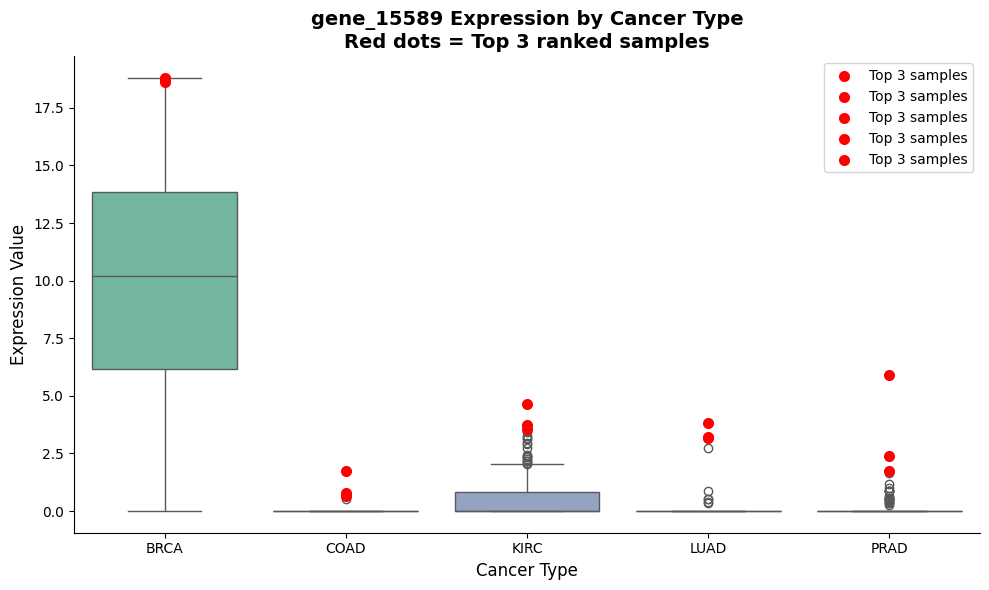

In [13]:
# --- Section 4: Visualization — Boxplot with top sample overlay ---
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_ranked,
    x="cancer_type_code",
    y="expression_value",
    hue="cancer_type_code",
    palette="Set2",
    ax=ax
)

sns.stripplot(
    data=df_top3,
    x="cancer_type_code",
    y="expression_value",
    color="red",
    size=8,
    jitter=False,
    label="Top 3 samples",
    ax=ax
)

ax.set_title("gene_15589 Expression by Cancer Type\nRed dots = Top 3 ranked samples", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Cancer Type", fontsize=12)
ax.set_ylabel("Expression Value", fontsize=12)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/section4_within_cancer_ranking.png", dpi=150)
plt.show()

## Section 5 — Key Findings

### 1. Sample Distribution
- BRCA is the largest group (300 samples), COAD the smallest (78 samples)
- Imbalanced distribution should be considered in any downstream modeling

### 2. Gene Expression Landscape
- Expression patterns vary considerably across cancer types and genes
- Some genes show consistent expression across all cancer types while others are highly type-specific

### 3. Above-Average Expression
- BRCA contributes the most above-average expression counts, partly reflecting its larger sample size
- Normalizing by sample count would give a fairer comparison across groups

### 4. Within-Cancer Ranking (gene_15589)
- BRCA shows the highest average expression for gene_15589
- COAD shows the lowest average expression for gene_15589
- KIRC, previously identified as a low-expression cancer type in the RNA-Seq EDA project,
  ranks in the middle for this specific gene — confirming that KIRC suppression is gene-selective,
  not global
- Window functions allow per-group ranking without losing row-level detail,
  making them essential for clinical data analysis

In [14]:
# --- Section 5: Summary Table ---
query = """
    SELECT
        p.cancer_type_code,
        c.full_name,
        COUNT(DISTINCT p.sample_id) AS total_samples,
        ROUND(AVG(g.expression_value)::numeric, 4) AS avg_expression_all_genes,
        ROUND(MAX(g.expression_value)::numeric, 4) AS max_expression,
        ROUND(MIN(g.expression_value)::numeric, 4) AS min_expression
    FROM patients p
    JOIN cancer_types c ON p.cancer_type_code = c.cancer_type_code
    JOIN gene_expression g ON p.sample_id = g.sample_id
    GROUP BY p.cancer_type_code, c.full_name
    ORDER BY avg_expression_all_genes DESC;
"""

with engine.connect() as conn:
    df_summary = pd.read_sql(query, conn)

df_summary

,cancer_type_code,full_name,total_samples,avg_expression_all_genes,max_expression,min_expression
0,PRAD,Prostate Adenocarcinoma,136,7.6326,20.5856,0.0
1,LUAD,Lung Adenocarcinoma,141,7.0694,20.3842,0.0
2,COAD,Colon Adenocarcinoma,78,6.0489,18.0129,0.0
3,BRCA,Breast Invasive Carcinoma,300,4.1138,18.7942,0.0
4,KIRC,Kidney Renal Clear Cell Carcinoma,146,3.9958,15.6909,0.0
